In [6]:
import numpy as np

file_structure = {
    "data": np.float32,   # [H, W]
    "mask": np.uint8,     # [H, W]
    "soft_mask": np.float32, # [H, W]
    "valid": np.uint8,    # [H, W]
    "meta": {
        "height": int,
        "width": int,
        "nodata_fill_value": float,
        "created_from": {
            "data_path": str,
            "mask_path": str
        }
    }
}

no_data_value = 0.0

# RAW DEM Data

In [ ]:
import numpy as np

dem_path = "/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/data/raw/DEM.npz"
mask_path = "/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/data/raw/Mounds_raster_mask_opened_closed.npy"

data = np.load(dem_path)
dem = data["dataset"].astype(np.float32)
valid = data["validMask"].astype(bool)
mask = np.load(mask_path).astype(np.bool)

f_name = "DEM_raw"

In [3]:
dem[~valid] = no_data_value

In [4]:
assert dem.shape == valid.shape
assert dem.shape == mask.shape
assert valid.shape == mask.shape

In [5]:
file_structure["data"] = np.stack([dem, dem, dem], axis=0)
file_structure["mask"] = mask
file_structure["soft_mask"] = None
file_structure["valid"] = valid

file_structure["meta"]["height"] = dem.shape[0]
file_structure["meta"]["width"] = dem.shape[1]
file_structure["meta"]["nodata_fill_value"] = no_data_value

file_structure["meta"]["created_from"]["data_path"] = dem_path
file_structure["meta"]["created_from"]["mask_path"] = mask_path

In [6]:
np.savez_compressed(f"../data/processed/{f_name}.npz", **file_structure)

# RAW DEM Dataset
- raw DEM
- confidence shadow mask

In [ ]:
import numpy as np

data_path = "/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_raw.npz"

data = np.load(data_path)
dem = data["data"].astype(np.float32)
mask = data["mask"].astype(np.float32)
valid = data["valid"].astype(np.uint8)

In [2]:
f_name = "DEM_raw_shadowed_6"

In [3]:
assert valid.shape == mask.shape

In [5]:
import numpy as np
from scipy.ndimage import distance_transform_edt

# input: mask -> 2D numpy array, binary labeling mask

resolution = 1  # meters per pixel

# paper values in meters
shadow_len_m = 6  # or 4

shadow_len_px = shadow_len_m / resolution

mask = (mask > 0).astype(np.uint8)

dist_outside = distance_transform_edt(mask == 0)

confidence_mask = np.where(
    mask == 1,
    1.0,
    np.clip(1.0 - dist_outside / shadow_len_px, 0.0, 1.0)  # pyright: ignore[reportOperatorIssue]
).astype(np.float32)

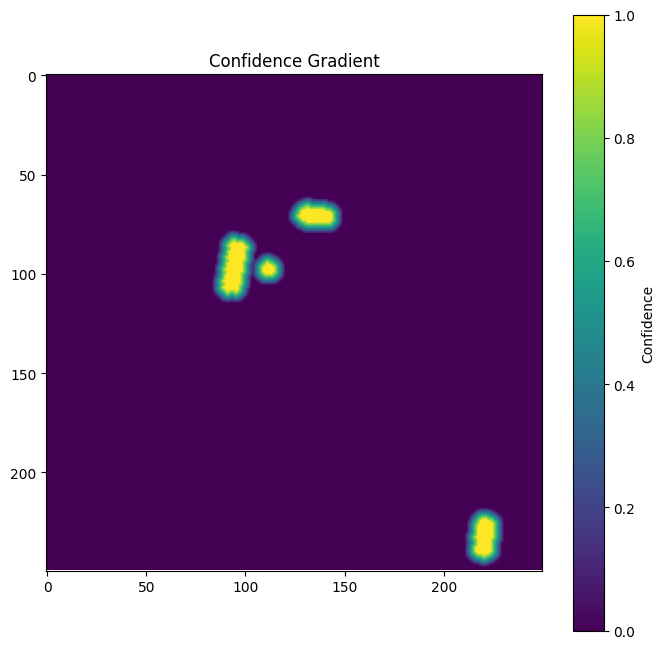

In [6]:
import matplotlib.pyplot as plt
    
patch = confidence_mask[3000:3250, 3000:3250]
plt.figure(figsize=(8, 8))
plt.imshow(patch, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Confidence')
plt.title('Confidence Gradient')
plt.show()

In [9]:
file_structure["data"] = dem if (dem.shape[0] == 3) else np.stack([dem, dem, dem], axis=0)
file_structure["mask"] = mask
file_structure["soft_mask"] = confidence_mask
file_structure["valid"] = valid

file_structure["meta"]["height"] = dem.shape[0]
file_structure["meta"]["width"] = dem.shape[1]
file_structure["meta"]["nodata_fill_value"] = no_data_value

file_structure["meta"]["created_from"]["data_path"] = data_path
file_structure["meta"]["created_from"]["mask_path"] = data_path

In [10]:
np.savez_compressed(f"../data/processed/{f_name}.npz", **file_structure)

# Normalized DEM Dataset
- Normalized DEM (z-score)
- Confidence Shadow masks 2m (yes/no)

In [1]:
import numpy as np

data_path = "/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_raw.npz"

data = np.load(data_path)
dem = data["data"].astype(np.float32)
mask = data["mask"].astype(np.float32)
valid = data["valid"].astype(np.bool)

In [9]:
radius = 2
f_name = f"DEM_norm_shadowed_{radius}"
#f_name = "DEM_norm"

## Normalize DEM

In [3]:
dem2d = dem[0]

mean_dem = dem2d[valid].mean()
std_dem = dem2d[valid].std()
std_dem = max(std_dem, 1e-6)

print("mean_dem:", mean_dem)
print("std_dem:", std_dem)

mean_dem: 186.29837
std_dem: 54.072247


In [ ]:
dem_z = np.zeros_like(dem2d, dtype=np.float32)
dem_z[valid] = (dem2d[valid] - mean_dem) / std_dem
dem_z[~valid] = no_data_value

print("mean_dem:", mean_dem)
print("std_dem:", std_dem)

## Apply shadow on masks

In [10]:
import numpy as np
from scipy.ndimage import distance_transform_edt

# input: mask -> 2D numpy array, binary labeling mask

resolution = 1  # meters per pixel

# paper values in meters
shadow_len_m = radius

shadow_len_px = shadow_len_m / resolution

mask = (mask > 0).astype(np.uint8)

dist_outside = distance_transform_edt(mask == 0)

confidence_mask = np.where(
    mask == 1,
    1.0,
    np.clip(1.0 - dist_outside / shadow_len_px, 0.0, 1.0)  # pyright: ignore[reportOperatorIssue]
).astype(np.float32)

## Output

In [11]:
file_structure["data"] = dem_z if (dem_z.shape[0] == 3) else np.stack([dem_z, dem_z, dem_z], axis=0)
file_structure["mask"] = mask
file_structure["soft_mask"] = confidence_mask
file_structure["valid"] = valid

file_structure["meta"]["height"] = dem.shape[0]
file_structure["meta"]["width"] = dem.shape[1]
file_structure["meta"]["nodata_fill_value"] = no_data_value

file_structure["meta"]["created_from"]["data_path"] = data_path
file_structure["meta"]["created_from"]["mask_path"] = data_path

In [12]:
np.savez_compressed(f"../data/processed/{f_name}.npz", **file_structure)

# RGB (ldr21_d_STU_General)

- RGB dataset
- Confidence Shadow mask

In [1]:
import rasterio

rgb_path = "/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/data/georef/ldr21_d_STU_General.tif"
dem_path = "/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/data/georef/DEM.tif"

# 1. Load training area bounding box
with rasterio.open(dem_path) as src_train:
    left, bottom, right, top = src_train.bounds

# 2. Load RGB and compute window
with rasterio.open(rgb_path) as src_rgb:
    window = rasterio.windows.from_bounds(
        left, bottom, right, top,
        transform=src_rgb.transform
    )
    rgb_crop = src_rgb.read(window=window)

# rgb_crop shape = (3, cropped_H, cropped_W)
print("Cropped RGB shape:", rgb_crop.shape)

Cropped RGB shape: (3, 17092, 9791)


In [21]:
radius = 2
f_name = f"RGDem(STU_norm)_shadowed_{radius}"

In [3]:
f_name = f"RGDem(STU_norm)"

In [4]:
import numpy as np

data_path = f"/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_raw_shadowed_{radius}.npz"

data = np.load(data_path)
dem = data["data"].astype(np.float32)
mask = data["mask"].astype(np.float32)
soft_mask = data["soft_mask"].astype(np.float32)
valid = data["valid"].astype(np.uint8)

In [5]:
assert mask.shape == rgb_crop[0].shape

## Crop area

### RGB raw

In [10]:
file_structure["data"] = rgb_crop
file_structure["mask"] = mask
file_structure["soft_mask"] = None
file_structure["valid"] = valid

file_structure["meta"]["height"] = rgb_crop.shape[0]
file_structure["meta"]["width"] = rgb_crop.shape[1]
file_structure["meta"]["nodata_fill_value"] = no_data_value

file_structure["meta"]["created_from"]["data_path"] = data_path
file_structure["meta"]["created_from"]["mask_path"] = data_path

### RGB shadowed

In [14]:
file_structure["data"] = rgb_crop
file_structure["mask"] = mask
file_structure["soft_mask"] = soft_mask
file_structure["valid"] = valid

file_structure["meta"]["height"] = rgb_crop.shape[0]
file_structure["meta"]["width"] = rgb_crop.shape[1]
file_structure["meta"]["nodata_fill_value"] = no_data_value

file_structure["meta"]["created_from"]["data_path"] = data_path
file_structure["meta"]["created_from"]["mask_path"] = data_path

### RGD (R, G, Dem_raw)

In [6]:
rgb_crop = rgb_crop.astype(np.float32)

In [7]:
assert rgb_crop[0].shape == dem[0].shape
assert rgb_crop.dtype == dem.dtype

#### raw DEM

In [7]:
rgb_crop[2] = dem[0]
rgb_crop.shape

(3, 17092, 9791)

##### normalized DEM

- z-score

In [8]:
valid_bool = valid.astype(bool)

rgb_crop = rgb_crop / 255.0

mean_rgb = np.array([
    rgb_crop[0][valid_bool].mean(),
    rgb_crop[1][valid_bool].mean(),
    rgb_crop[2][valid_bool].mean(),
], dtype=np.float32)

std_rgb = np.array([
    rgb_crop[0][valid_bool].std(),
    rgb_crop[1][valid_bool].std(),
    rgb_crop[2][valid_bool].std(),
], dtype=np.float32)

std_rgb = np.maximum(std_rgb, 1e-6)

print("mean_rgb:", mean_rgb)
print("std_rgb:", std_rgb)

mean_rgb: [0.53939015 0.534676   0.5223476 ]
std_rgb: [0.10136034 0.09958455 0.10287824]


In [9]:
dem2d = dem[0]

mean_dem = dem2d[valid_bool].mean()
std_dem = dem2d[valid_bool].std()
std_dem = max(std_dem, 1e-6)

print("mean_dem:", mean_dem)
print("std_dem:", std_dem)

mean_dem: 186.29837
std_dem: 54.072247


In [10]:
rgb_z = np.empty_like(rgb_crop, dtype=np.float32)

for c in range(3):
    rgb_z[c] = (rgb_crop[c] - mean_rgb[c]) / std_rgb[c]

In [ ]:
dem_z = np.zeros_like(dem2d, dtype=np.float32)
dem_z[valid_bool] = (dem2d[valid_bool] - mean_dem) / std_dem
dem_z[~valid_bool] = no_data_value

In [13]:
assert dem_z.shape == rgb_z[0].shape

In [14]:
rgb_z[2] = dem_z
rgb_z.shape

(3, 17092, 9791)

In [20]:
file_structure["data"] = rgb_z
file_structure["mask"] = mask
file_structure["soft_mask"] = soft_mask
file_structure["valid"] = valid

file_structure["meta"]["height"] = rgb_crop.shape[0]
file_structure["meta"]["width"] = rgb_crop.shape[1]
file_structure["meta"]["nodata_fill_value"] = no_data_value

file_structure["meta"]["created_from"]["data_path"] = data_path
file_structure["meta"]["created_from"]["mask_path"] = data_path

In [22]:
np.savez_compressed(f"../data/processed/{f_name}.npz", **file_structure)

# SPS
- Slope
- Positive Opennes
- Sky-view factor

* Confidence Shadow 2m (yes/no)

In [14]:
radius = 2
kernel_radius = 12

f_name = f"SPS(znorm)_{kernel_radius}_shadowed_{radius}"
#f_name = f"SPS(znorm)_{kernel_radius}"

In [2]:
import numpy as np

data_path = f"/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_raw_shadowed_{radius}.npz"

data = np.load(data_path)
#dem = data["data"].astype(np.float32)
mask = data["mask"].astype(np.float32)
soft_mask = data["soft_mask"].astype(np.float32)
valid = data["valid"].astype(np.uint8)

In [3]:
import rasterio
data_dir = "/home/nikitachernysh/Storage/Projects/lidar-archaeology-segmentation/data/georef/"

files = ["slope.tif", f"svf_{kernel_radius}.tif", f"positive_openness_{kernel_radius}.tif"]
arrs = [rasterio.open(data_dir+f).read(1).astype(np.float32) for f in files]
assert len({a.shape for a in arrs}) == 1, "Shapes mismatch"
SPS = np.stack(arrs, axis=0)  # (3, H, W)

In [4]:
print(np.isnan(SPS).sum())
print((~valid.astype(np.bool)).sum())

15273150
5072579


In [7]:
valid_bool = valid.astype(np.bool)
nan_mask = np.isnan(SPS).any(axis=0)  # (H, W)

valid = valid_bool & (~nan_mask)

SPS = np.nan_to_num(SPS, nan=no_data_value)

In [8]:
def zscore(x, mask):
    m = x[mask].mean()
    s = x[mask].std()
    x = (x - m) / (s + 1e-8)
    x[~mask] = no_data_value
    return x

for c in range(3):
    SPS[c] = zscore(SPS[c], valid)

In [9]:
assert SPS[0].shape == mask.shape, f"{SPS[0].shape},{mask.shape}"
assert SPS[1].shape == mask.shape, f"{SPS[1].shape},{mask.shape}"
assert SPS[2].shape == mask.shape, f"{SPS[2].shape},{mask.shape}"

assert SPS[0].shape == soft_mask.shape, f"{SPS[0].shape},{soft_mask.shape}"
assert SPS[1].shape == soft_mask.shape, f"{SPS[1].shape},{soft_mask.shape}"
assert SPS[2].shape == soft_mask.shape, f"{SPS[2].shape},{soft_mask.shape}"

assert SPS[0].shape == valid.shape, f"{SPS[0].shape},{valid.shape}"
assert SPS[1].shape == valid.shape, f"{SPS[1].shape},{valid.shape}"
assert SPS[2].shape == valid.shape, f"{SPS[2].shape},{valid.shape}"

assert np.isnan(SPS).sum() == 0, np.isnan(SPS).sum()

In [17]:
file_structure["data"] = SPS
file_structure["mask"] = mask
file_structure["soft_mask"] = soft_mask
file_structure["valid"] = valid

file_structure["meta"]["height"] = SPS[0].shape[0]
file_structure["meta"]["width"] = SPS[0].shape[1]
file_structure["meta"]["nodata_fill_value"] = no_data_value

file_structure["meta"]["created_from"]["data_path"] = data_path
file_structure["meta"]["created_from"]["mask_path"] = data_path

In [18]:
np.savez_compressed(f"../data/processed/{f_name}.npz", **file_structure)

# SPS + DEM

1. DEM + Slope + SVF
2. DEM + 